# Building the Missing Lamb & Goat Price Index

Notebook 02 found that sheep/goat is the **fastest-growing US meat in percentage terms**
(+2.7%/yr) and the second-fastest globally — yet it has **no futures contract, no national
price index, and thin retail price data**. Price discovery happens across hundreds of small
terminal auctions, and producers routinely don't know what their animals are worth.

This notebook starts fixing that. USDA Market News *does* collect the raw prices — they're just
scattered across per-auction reports nobody aggregates. Two access tiers:

| Tier | Access | What you get |
|---|---|---|
| **1 — keyless** (runs today) | `ams.usda.gov/mnreports/*.txt` | The *latest* National Sheep Summary; each run archives a dated copy to `data/mnreports/`, so scheduling this weekly accumulates a history for free |
| **2 — free API key** | MARS "My Market News" JSON API | The full multi-year archive of every sheep **and goat** auction, structured (head counts, weight ranges, grades, prices) |

**This notebook:**
1. Fetch and parse this week's national summary (tier 1)
2. Measure the inefficiency directly: how much does the *same class of lamb* sell for across
   different auction markets in the same week?
3. Build the index skeleton from the accumulating archive
4. Tier 2: with a MARS key, pull multi-year San Angelo + New Holland history and extend the
   index back in time (runs automatically once a key is present)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from mars_pipeline import (
    fetch_text_report,
    parse_national_summary,
    get_mars_key,
    find_sheep_goat_reports,
    fetch_auction_history,
    ARCHIVE_DIR,
)

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"

# --- Tier 1: this week's Weekly National Sheep Summary ----------------------
text = fetch_text_report("sa_ls855")
obs = parse_national_summary(text)
print(f"{len(obs)} price observations, report dated {obs['report_date'].iloc[0]:%Y-%m-%d}")
print(f"Markets: {', '.join(sorted(obs['market'].unique()))}")
obs.head(10)

47 price observations, report dated 2026-08-07
Markets: Billings, Ft. Collins, Kalona, Missouri, Mount Hope, New Holland, San Angelo, Sioux Falls


,report_date,category,grade,market,weight_low_lbs,weight_high_lbs,price_low_cwt,price_high_cwt,price_mid_cwt
0,2026-08-07,Slaughter Lambs,Choice and Prime 1-3,San Angelo,80,90,297.0,297.0,297.0
1,2026-08-07,Slaughter Lambs,Choice and Prime 1-3,San Angelo,100,110,259.0,282.0,270.5
2,2026-08-07,Slaughter Lambs,Choice and Prime 1-3,New Holland,50,60,300.0,375.0,337.5
3,2026-08-07,Slaughter Lambs,Choice and Prime 1-3,New Holland,60,70,310.0,360.0,335.0
4,2026-08-07,Slaughter Lambs,Choice and Prime 1-3,New Holland,70,80,290.0,340.0,315.0
5,2026-08-07,Slaughter Lambs,Choice and Prime 1-3,New Holland,80,90,285.0,315.0,300.0
6,2026-08-07,Slaughter Lambs,Choice and Prime 1-3,New Holland,90,100,285.0,350.0,317.5
7,2026-08-07,Slaughter Lambs,Choice and Prime 1-3,New Holland,100,110,275.0,310.0,292.5
8,2026-08-07,Slaughter Lambs,Choice and Prime 1-3,New Holland,110,120,295.0,315.0,305.0
9,2026-08-07,Slaughter Lambs,Choice and Prime 1-3,Ft. Collins,50,60,295.0,345.0,320.0


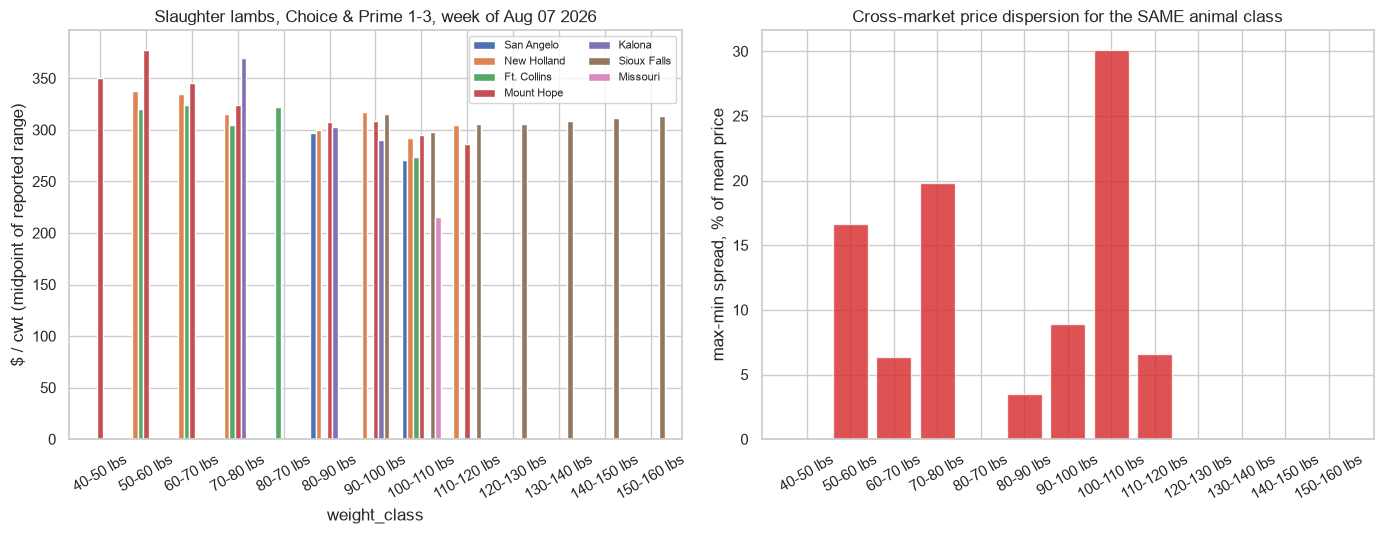

Same-week, same-class price dispersion across US auction markets:
  40-50 lbs      0.0% spread across 1 markets ($350 to $350/cwt)
  50-60 lbs     16.7% spread across 3 markets ($320 to $378/cwt)
  60-70 lbs      6.4% spread across 3 markets ($324 to $345/cwt)
  70-80 lbs     19.8% spread across 4 markets ($305 to $370/cwt)
  80-70 lbs      0.0% spread across 1 markets ($322 to $322/cwt)
  80-90 lbs      3.5% spread across 4 markets ($297 to $308/cwt)
  90-100 lbs     8.9% spread across 4 markets ($290 to $318/cwt)
  100-110 lbs   30.1% spread across 6 markets ($215 to $298/cwt)
  110-120 lbs    6.6% spread across 3 markets ($286 to $306/cwt)
  120-130 lbs    0.0% spread across 1 markets ($306 to $306/cwt)
  130-140 lbs    0.0% spread across 1 markets ($309 to $309/cwt)
  140-150 lbs    0.0% spread across 1 markets ($312 to $312/cwt)
  150-160 lbs    0.0% spread across 1 markets ($313 to $313/cwt)


In [2]:
# --- 2. The inefficiency, measured ------------------------------------------
# Same week, same category/grade, same weight class -> how far apart are markets?
lambs = obs[obs["category"] == "Slaughter Lambs"].copy()
lambs["weight_class"] = (
    lambs["weight_low_lbs"].astype(str) + "-" + lambs["weight_high_lbs"].astype(str) + " lbs"
)

# Cross-market average per weight class = crude "national price"
lambs["national_avg_cwt"] = lambs.groupby("weight_class")["price_mid_cwt"].transform("mean")
lambs["basis_vs_national"] = lambs["price_mid_cwt"] - lambs["national_avg_cwt"]

pivot = lambs.pivot_table(
    index="weight_class", columns="market", values="price_mid_cwt",
    sort=False,
).sort_index(key=lambda ix: ix.str.split("-").str[0].astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
pivot.plot(kind="bar", ax=axes[0], width=0.85)
axes[0].set_ylabel("$ / cwt (midpoint of reported range)")
axes[0].set_title(f"Slaughter lambs, Choice & Prime 1-3, week of {obs['report_date'].iloc[0]:%b %d %Y}")
axes[0].legend(fontsize=8, ncol=2)
axes[0].tick_params(axis="x", rotation=30)

spread = pivot.max(axis=1) - pivot.min(axis=1)
spread_pct = 100 * spread / pivot.mean(axis=1)
axes[1].bar(range(len(spread_pct)), spread_pct.values, color="tab:red", alpha=0.8)
axes[1].set_xticks(range(len(spread_pct)), spread_pct.index, rotation=30)
axes[1].set_ylabel("max-min spread, % of mean price")
axes[1].set_title("Cross-market price dispersion for the SAME animal class")

plt.tight_layout()
plt.savefig(FIG_DIR / "10_market_dispersion.png", dpi=150, bbox_inches="tight")
plt.show()

print("Same-week, same-class price dispersion across US auction markets:")
for wc, pct in spread_pct.dropna().items():
    n = pivot.loc[wc].notna().sum()
    if n >= 2:
        print(f"  {wc:<12} {pct:5.1f}% spread across {n} markets "
              f"(${pivot.loc[wc].min():.0f} to ${pivot.loc[wc].max():.0f}/cwt)")

Part of the dispersion above is real (freight, lot size, local demand — e.g. New Holland PA
serves the East Coast ethnic/halal market and persistently prices light lambs above western
markets), but dispersion this wide *within one week for one grade* is exactly what "thin price
discovery" looks like in cattle-free markets. A producer selling at the wrong barn leaves real
money on the table — and quantifying that gap by market is the value of an index.

## 3. Index skeleton from the accumulating archive

Every run of this notebook (or of `mars_pipeline.py` on a schedule) saves a dated copy of the
report. The cell below parses **all** archived copies into a weekly national index:
the average slaughter-lamb price across markets, weight-class-balanced so a heavy-lamb week
doesn't masquerade as a price drop. With one archived week it's a single point; schedule the
fetch weekly (Windows Task Scheduler / n8n) and the series builds itself.

Archived weeks so far: 1
report_date
2026-08-07    318.260417
Name: us_slaughter_lamb_cwt, dtype: float64


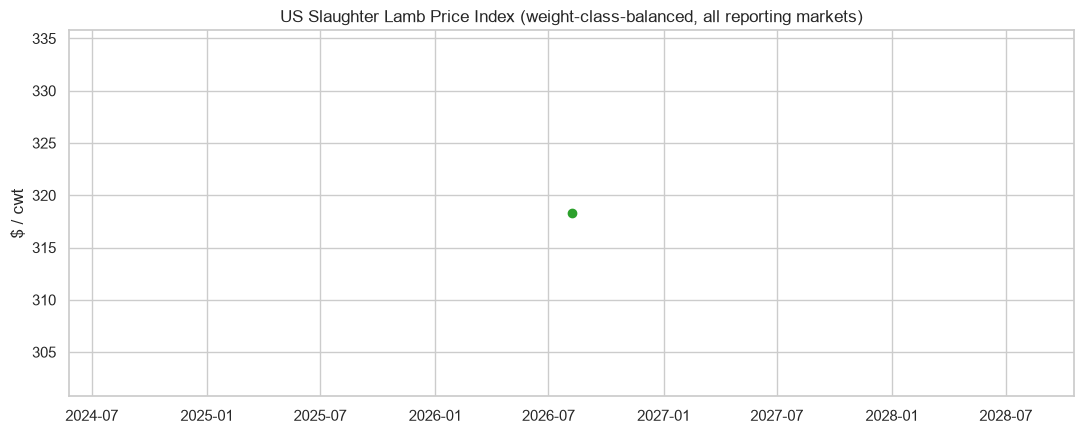

In [3]:
# --- 3. Weekly index from archived reports -----------------------------------
def build_index_from_archive() -> pd.Series:
    frames = []
    for f in sorted(ARCHIVE_DIR.glob("sa_ls855_*.txt")):
        parsed = parse_national_summary(f.read_text(encoding="utf-8"))
        if not parsed.empty:
            frames.append(parsed)
    if not frames:
        return pd.Series(dtype=float)
    allobs = pd.concat(frames).drop_duplicates(
        subset=["report_date", "category", "market", "weight_low_lbs"]
    )
    lambs = allobs[allobs["category"] == "Slaughter Lambs"]
    # Weight-class-balanced: average markets within each weight class first,
    # then average weight classes, so composition shifts don't move the index.
    by_class = (
        lambs.groupby(["report_date", "weight_low_lbs"])["price_mid_cwt"].mean()
    )
    return by_class.groupby("report_date").mean().rename("us_slaughter_lamb_cwt")

index = build_index_from_archive()
print(f"Archived weeks so far: {len(index)}")
print(index)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(index.index, index.values, marker="o", lw=2, color="tab:green")
ax.set_ylabel("$ / cwt")
ax.set_title("US Slaughter Lamb Price Index (weight-class-balanced, all reporting markets)")
plt.tight_layout()
plt.savefig(FIG_DIR / "11_lamb_index.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Tier 2: full history via the MARS API (free key)

The structured JSON API unlocks the real prize: **multi-year history for every auction,
including the goat sales** (which are only published as PDFs on the keyless tier). Setup, once:

1. Register free at [mymarketnews.ams.usda.gov](https://mymarketnews.ams.usda.gov) (eAuth signup)
2. Click your name → **Show API key** → copy it
3. Paste it into a file named `.mars_api_key` in the project root (it's gitignored), or set the
   `MARS_API_KEY` environment variable

The cell below detects the key automatically: it discovers every sheep/goat/lamb report in the
MARS catalog, then pulls the last 3 years of the two flagship markets — San Angelo, TX
(slug 2014, the largest sheep/goat auction in the country) and New Holland, PA (slug 1913,
the East Coast ethnic-market benchmark) — and rebuilds the index with actual history.

In [4]:
# --- 4. MARS historical pull (runs automatically once a key is present) ------
from datetime import date, timedelta

if get_mars_key() is None:
    print("No MARS API key found - skipping the historical pull.")
    print("Follow the 3 setup steps above, then re-run this cell.")
else:
    catalog = find_sheep_goat_reports()
    print(f"MARS catalog: {len(catalog)} sheep/goat/lamb reports available")

    end = date.today()
    begin = end - timedelta(days=3 * 365)
    b, e = f"{begin:%m/%d/%Y}", f"{end:%m/%d/%Y}"

    histories = {}
    for slug, name in {2014: "San Angelo, TX", 1913: "New Holland, PA"}.items():
        try:
            df = fetch_auction_history(slug, b, e)
            histories[name] = df
            print(f"{name}: {len(df):,} rows, columns: {list(df.columns)[:12]}...")
        except Exception as exc:
            print(f"{name} (slug {slug}) failed: {exc}")

    if histories:
        fig, ax = plt.subplots(figsize=(12, 5))
        for name, df in histories.items():
            # Column names in MARS vary slightly by report; find the usual ones.
            date_col = next((c for c in df.columns if "report_date" in c.lower()), None)
            price_col = next(
                (c for c in df.columns if "avg_price" in c.lower() or c.lower() == "price"),
                None,
            )
            if not (date_col and price_col):
                print(f"{name}: could not locate date/price columns - inspect manually.")
                continue
            df = df.copy()
            df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
            df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
            weekly = df.dropna(subset=[date_col, price_col]).set_index(date_col)[
                price_col
            ].resample("W").mean()
            ax.plot(weekly.index, weekly.values, lw=1.5, label=name)
        ax.set_ylabel("$ / cwt (all classes, weekly mean)")
        ax.set_title("Sheep & goat auction prices - MARS historical data")
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / "12_mars_history.png", dpi=150, bbox_inches="tight")
        plt.show()

No MARS API key found - skipping the historical pull.
Follow the 3 setup steps above, then re-run this cell.


## Roadmap: from notebook to public index

1. **Get the MARS key** (5 minutes) → re-run this notebook → 3 years of San Angelo + New Holland
   history, including **goat classes** (kids, nannies, billies by selection grade), which is the
   truly unserved market.
2. **Schedule the tier-1 fetch weekly** (Task Scheduler or n8n — same pattern as the TableFlow
   automations) so the archive grows even without the API.
3. **Quality-adjust the index**: hedonic regression of price on weight, grade, market, and lot
   size, so the index tracks *price* rather than *composition*. This is the step that makes it
   methodologically defensible to LMIC/academic eyes.
4. **Publish**: auto-updating page (Next.js + a cron job) showing the index, per-market basis
   ("your barn vs the national average"), and week-over-week trends.
5. **Write the note**: "The US goat market is growing 2.7% a year and nobody knows the price" —
   your own charts, sent to LMIC, the American Sheep Industry Association, and the American
   Lamb Board.